# app

11 — MobileNetV3 Architecture Evolution

Эволюционный поиск архитектурной конфигурации классификационной части `MobileNetV3 Small` при сохранении стандартного предобученного backbone.

В отличие от ноутбука `10_mobilenet_evolutionary_search.ipynb`, здесь параметры обучения фиксируются по лучшей найденной конфигурации, а эволюция изменяет только архитектурные гены:

- тип классификационной головы;
- размер скрытого слоя;
- bottleneck ratio для двухслойной головы;
- dropout;
- функцию активации;
- тип pooling;
- нормализацию в голове;
- режим дообучения backbone.

Стандартная `MobileNetV3 Small` не меняется по `width_mult`, `reduced_tail`, `kernel_size`, числу блоков и каналам, поэтому предобученные ImageNet-веса загружаются без нарушения формы слоёв.

## bootstrap

In [ ]:
import os
from pathlib import Path

def is_colab() -> bool:
    try:
        import google.colab  # type: ignore
        return True
    except ImportError:
        return False
    

IN_COLAB = is_colab()

if IN_COLAB:
    REPO_ROOT = Path("/content") / "BrazingSense"
else:
    REPO_ROOT = Path.cwd().resolve()

if not (REPO_ROOT / ".git").exists():
    raise RuntimeError(f"REPO_ROOT не похож на корень репозитория: {REPO_ROOT}")

os.chdir(REPO_ROOT)

## packages

In [ ]:
from pathlib import Path
import json
import time
import random
import warnings
from copy import deepcopy

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")

## env

In [ ]:
FPS = 10
ROOT = Path()
DRIVE_FOLDER = Path("/content/drive/MyDrive/Colab Notebooks/Diploma")
EXPERIMENT_NAME = "mobilenet_architecture_evolution"

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cuda')

In [ ]:
DATA = ROOT / "data"

SPLITS_DIR = DATA / "annotations" / f"splits_{FPS}"
TRAIN_PATH = SPLITS_DIR / "train.csv"
VAL_PATH = SPLITS_DIR / "val.csv"
TEST_PATH = SPLITS_DIR / "test.csv"

DATA_PROCESSED = DATA / "processed"
DATA_PROCESSED_FRAMES = DATA_PROCESSED / f"frames_{FPS}"
DRIVE_PROCESSED_FRAMES_FOLDER = DRIVE_FOLDER / DATA_PROCESSED_FRAMES

DATA_RAW = DATA / "raw"
DRIVE_DATA_RAW = DRIVE_FOLDER / DATA_RAW

assert TRAIN_PATH.exists(), TRAIN_PATH
assert VAL_PATH.exists(), VAL_PATH
assert TEST_PATH.exists(), TEST_PATH

In [ ]:
MODELS_DIR = ROOT / "models"
CHECKPOINTS_DIR = MODELS_DIR / "checkpoints" / EXPERIMENT_NAME
DRIVE_CHECKPOINTS_DIR = DRIVE_FOLDER / CHECKPOINTS_DIR

CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)
if IN_COLAB:
    DRIVE_CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
REPORTS_ROOT = ROOT / "reports"
FIGURES_ROOT = ROOT / "reports" / "figures"
REPORTS_DIR = REPORTS_ROOT / EXPERIMENT_NAME
FIGURES_DIR = FIGURES_ROOT / EXPERIMENT_NAME

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
STAGE_ORDER = [
    "inactive_preparation",
    "flux_activation",
    "active_brazing",
    "stabilization",
]

STAGE_TO_ID = {
    "inactive_preparation": 0,
    "flux_activation": 1,
    "active_brazing": 2,
    "stabilization": 3,
}

ID_TO_STAGE = {v: k for k, v in STAGE_TO_ID.items()}

ROI = {
    "x": 470,
    "y": 280,
    "w": 430,
    "h": 290,
}

NUM_CLASSES = 4

# lib

In [ ]:
def resolve_path(path_value: str) -> Path:
    path = Path(path_value)
    if path.is_absolute():
        return path
    return ROOT / path


def read_rgb_image(path: Path) -> np.ndarray:
    image_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise ValueError(f"Could not read image: {path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def crop_roi(image: np.ndarray, roi: dict) -> np.ndarray:
    x, y, w, h = roi["x"], roi["y"], roi["w"], roi["h"]
    return image[y:y + h, x:x + w]

<!-- # model -->

In [ ]:
class BrazingStageDataset(Dataset):
    def __init__(self, df: pd.DataFrame, roi: dict, transform=None):
        self.df = df.reset_index(drop=True).copy()
        self.roi = roi
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]

        image_path = resolve_path(row["frame_path"])
        image = read_rgb_image(image_path)
        image = crop_roi(image, self.roi)

        if self.transform is not None:
            image = self.transform(image)

        label = int(row["stage_id"])

        metadata = {
            "video_id": row["video_id"],
            "frame_path": row["frame_path"],
            "timestamp_s": float(row["timestamp_s"]),
            "stage_name": row["stage_name"],
        }

        return image, label, metadata

# runtime

<!-- ## configs -->

In [ ]:
# Лучшие параметры обучения из 10-го ноутбука.
FIXED_TRAINING_CONFIG = {
    "image_size": 224,
    "lr": 1e-4,
    "weight_decay": 3e-4,
    "active_brazing_boost": 1.2,
    "augmentation": "low",
}

FIXED_TRAINING_CONFIG

{'image_size': 224,
 'lr': 0.0001,
 'weight_decay': 0.0003,
 'active_brazing_boost': 1.2,
 'augmentation': 'low'}

In [ ]:
ARCH_SEARCH_SPACE_PRETRAINED = {
    "head_type": ["linear", "mlp_1", "mlp_2"],
    "head_hidden": [128, 256, 512],
    "head_bottleneck_ratio": [0.5, 1.0],
    "dropout": [0.1, 0.2, 0.3],
    "activation": ["relu", "hardswish", "gelu"],
    "pooling": ["avg", "avg_max"],
    "head_norm": ["none", "batchnorm"],
    "freeze_mode": ["last_blocks", "full"],
}

total_full_grid = 1
for values in ARCH_SEARCH_SPACE_PRETRAINED.values():
    total_full_grid *= len(values)

total_full_grid

1296

## data

In [ ]:
import subprocess

if IN_COLAB:
    from google.colab import drive # type: ignore
    drive.mount("/content/drive")

    copy_frames = ["cp", "-r", f"{DRIVE_PROCESSED_FRAMES_FOLDER}/.", f"{DATA_PROCESSED_FRAMES}/"]
    with open("copy_frames.log", "w") as frames_log:
        copy_frames_process = subprocess.Popen(copy_frames, stdout=frames_log, stderr=subprocess.STDOUT, text=True)

    # copy_checkpoints = ["cp", "-r", f"{DRIVE_CHECKPOINTS_DIR}/.", f"{CHECKPOINTS_DIR}/"]
    # with open("copy_checkpoints.log", "w") as checkpoints_log:
    #     copy_checkpoints_process = subprocess.Popen(copy_checkpoints, stdout=checkpoints_log, stderr=subprocess.STDOUT, text=True)

    # copy_raw_data = ["cp", "-r", f"{DRIVE_DATA_RAW}/.", f"{DATA_RAW}/"]
    # with open("copy_raw_data.log", "w") as data_log:
    #     copy_raw_data_process = subprocess.Popen(copy_raw_data, stdout=data_log, stderr=subprocess.STDOUT, text=True)

    # !cp -r -v "$DRIVE_PROCESSED_FRAMES_FOLDER"/. "$DATA_PROCESSED_FRAMES"/

Mounted at /content/drive


In [ ]:
print("Process", copy_frames_process.poll())
# !tail frames_log.log

Process None


In [ ]:
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

print("train:", train_df.shape)
print("val:", val_df.shape)
print("test:", test_df.shape)

def stage_counts(df: pd.DataFrame) -> pd.Series:
    return df.groupby("stage_name").size().reindex(STAGE_ORDER).fillna(0).astype(int)

split_counts = pd.DataFrame({
    "train": stage_counts(train_df),
    "val": stage_counts(val_df),
    "test": stage_counts(test_df),
})

split_counts

train: (5755, 8)
val: (1091, 8)
test: (1732, 8)


,train,val,test
stage_name,,,
inactive_preparation,3552,734,1000
flux_activation,506,102,138
active_brazing,766,138,196
stabilization,931,117,398


## transforms / dataloaders

In [ ]:
def make_transforms(image_size: int, augmentation: str = "low"):
    if augmentation == "none":
        train_transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
            ),
        ])

    elif augmentation == "low":
        train_transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((image_size, image_size)),
            transforms.RandomApply([
                transforms.ColorJitter(
                    brightness=0.08,
                    contrast=0.08,
                    saturation=0.05,
                    hue=0.01,
                )
            ], p=0.4),
            transforms.RandomRotation(degrees=2),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
            ),
        ])

    elif augmentation == "medium":
        train_transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((image_size, image_size)),
            transforms.RandomApply([
                transforms.ColorJitter(
                    brightness=0.15,
                    contrast=0.15,
                    saturation=0.10,
                    hue=0.02,
                )
            ], p=0.6),
            transforms.RandomApply([
                transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.8))
            ], p=0.15),
            transforms.RandomRotation(degrees=3),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
            ),
        ])

    else:
        raise ValueError(f"Unknown augmentation: {augmentation}")

    eval_transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ])

    return train_transform, eval_transform

In [ ]:
BATCH_SIZE = 32
NUM_WORKERS = 2

def make_dataloaders(image_size: int, augmentation: str = "low"):
    train_transform, eval_transform = make_transforms(
        image_size=image_size,
        augmentation=augmentation,
    )

    train_dataset = BrazingStageDataset(train_df, roi=ROI, transform=train_transform)
    val_dataset = BrazingStageDataset(val_df, roi=ROI, transform=eval_transform)
    test_dataset = BrazingStageDataset(test_df, roi=ROI, transform=eval_transform)

    loader_kwargs = dict(
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

    train_loader = DataLoader(train_dataset, shuffle=True, **loader_kwargs)
    val_loader = DataLoader(val_dataset, shuffle=False, **loader_kwargs)
    test_loader = DataLoader(test_dataset, shuffle=False, **loader_kwargs)

    return train_loader, val_loader, test_loader

## class weights

In [ ]:
def make_class_weights(train_df: pd.DataFrame, active_brazing_boost: float = 1.0):
    train_counts = train_df["stage_id"].value_counts().sort_index()
    train_counts = train_counts.reindex([0, 1, 2, 3]).fillna(0).astype(int)

    total = train_counts.sum()
    num_classes = len(train_counts)

    weights = total / (num_classes * train_counts.values)
    weights = weights.astype(np.float32)

    # active_brazing = class 2
    weights[2] *= active_brazing_boost

    return torch.tensor(weights, dtype=torch.float32).to(DEVICE)


make_class_weights(
    train_df,
    active_brazing_boost=FIXED_TRAINING_CONFIG["active_brazing_boost"],
)

tensor([0.4051, 2.8434, 2.2539, 1.5454], device='cuda:0')

## model factory

In [ ]:
def make_activation(name: str):
    if name == "relu":
        return nn.ReLU(inplace=True)
    if name == "hardswish":
        return nn.Hardswish(inplace=True)
    if name == "gelu":
        return nn.GELU()
    raise ValueError(f"Unknown activation: {name}")


def make_norm(norm_name: str, num_features: int):
    if norm_name == "none":
        return None
    if norm_name == "batchnorm":
        return nn.BatchNorm1d(num_features)
    raise ValueError(f"Unknown head_norm: {norm_name}")

In [ ]:
class AvgMaxPool2d(nn.Module):
    def __init__(self):
        super().__init__()
        self.avg = nn.AdaptiveAvgPool2d(1)
        self.max = nn.AdaptiveMaxPool2d(1)

    def forward(self, x):
        avg_x = self.avg(x)
        max_x = self.max(x)
        return torch.cat([avg_x, max_x], dim=1)

In [ ]:
class MobileNetV3SmallEvo(nn.Module):
    def __init__(
        self,
        num_classes: int,
        head_type: str,
        head_hidden: int,
        head_bottleneck_ratio: float,
        dropout: float,
        activation: str,
        pooling: str,
        head_norm: str,
        freeze_mode: str,
        pretrained: bool = True,
        unfreeze_last_n_blocks: int = 3,
    ):
        super().__init__()

        # Стандартная MobileNetV3 Small:
        # width_mult и reduced_tail не меняются, поэтому weights грузятся штатно.
        weights = models.MobileNet_V3_Small_Weights.DEFAULT if pretrained else None
        base = models.mobilenet_v3_small(weights=weights)

        self.features = base.features

        # Для стандартной MobileNetV3 Small classifier[0].in_features соответствует
        # числу каналов после backbone.
        backbone_feature_dim = base.classifier[0].in_features

        if pooling == "avg":
            self.pool = nn.AdaptiveAvgPool2d(1)
            pooled_dim = backbone_feature_dim
        elif pooling == "avg_max":
            self.pool = AvgMaxPool2d()
            pooled_dim = backbone_feature_dim * 2
        else:
            raise ValueError(f"Unknown pooling: {pooling}")

        self.flatten = nn.Flatten(1)

        self.classifier = self._make_head(
            in_features=pooled_dim,
            num_classes=num_classes,
            head_type=head_type,
            head_hidden=head_hidden,
            head_bottleneck_ratio=head_bottleneck_ratio,
            dropout=dropout,
            activation=activation,
            head_norm=head_norm,
        )

        self.apply_freeze_mode(
            freeze_mode=freeze_mode,
            unfreeze_last_n_blocks=unfreeze_last_n_blocks,
        )

        self.arch_config = {
            "head_type": head_type,
            "head_hidden": head_hidden,
            "head_bottleneck_ratio": head_bottleneck_ratio,
            "dropout": dropout,
            "activation": activation,
            "pooling": pooling,
            "head_norm": head_norm,
            "freeze_mode": freeze_mode,
            "pretrained": pretrained,
            "unfreeze_last_n_blocks": unfreeze_last_n_blocks,
        }

    def _make_head(
        self,
        in_features: int,
        num_classes: int,
        head_type: str,
        head_hidden: int,
        head_bottleneck_ratio: float,
        dropout: float,
        activation: str,
        head_norm: str,
    ) -> nn.Sequential:
        act = make_activation(activation)

        def maybe_norm(n: int):
            norm = make_norm(head_norm, n)
            return [] if norm is None else [norm]

        if head_type == "linear":
            layers = [
                *maybe_norm(in_features),
                nn.Dropout(p=dropout),
                nn.Linear(in_features, num_classes),
            ]

        elif head_type == "mlp_1":
            layers = [
                nn.Linear(in_features, head_hidden),
                *maybe_norm(head_hidden),
                act,
                nn.Dropout(p=dropout),
                nn.Linear(head_hidden, num_classes),
            ]

        elif head_type == "mlp_2":
            bottleneck_hidden = max(
                32,
                int(round(head_hidden * float(head_bottleneck_ratio))),
            )

            layers = [
                nn.Linear(in_features, head_hidden),
                *maybe_norm(head_hidden),
                act,
                nn.Dropout(p=dropout),
                nn.Linear(head_hidden, bottleneck_hidden),
                *maybe_norm(bottleneck_hidden),
                make_activation(activation),
                nn.Dropout(p=dropout),
                nn.Linear(bottleneck_hidden, num_classes),
            ]

        else:
            raise ValueError(f"Unknown head_type: {head_type}")

        return nn.Sequential(*layers)

    def apply_freeze_mode(self, freeze_mode: str, unfreeze_last_n_blocks: int = 3):
        # classifier всегда обучается
        for p in self.classifier.parameters():
            p.requires_grad = True

        if freeze_mode == "full":
            for p in self.features.parameters():
                p.requires_grad = True

        elif freeze_mode == "last_blocks":
            for p in self.features.parameters():
                p.requires_grad = False

            for block in self.features[-unfreeze_last_n_blocks:]:
                for p in block.parameters():
                    p.requires_grad = True

        else:
            raise ValueError(f"Unknown freeze_mode: {freeze_mode}")

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.flatten(x)
        x = self.classifier(x)
        return x

In [ ]:
def create_mobilenet_v3_small_evo(candidate: dict, num_classes: int = NUM_CLASSES, pretrained: bool = True):
    return MobileNetV3SmallEvo(
        num_classes=num_classes,
        head_type=candidate["head_type"],
        head_hidden=int(candidate["head_hidden"]),
        head_bottleneck_ratio=float(candidate["head_bottleneck_ratio"]),
        dropout=float(candidate["dropout"]),
        activation=candidate["activation"],
        pooling=candidate["pooling"],
        head_norm=candidate["head_norm"],
        freeze_mode=candidate["freeze_mode"],
        pretrained=pretrained,
    )


def count_parameters(model: nn.Module) -> dict:
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    classifier = sum(p.numel() for p in model.classifier.parameters())
    return {
        "num_params": int(total),
        "num_trainable_params": int(trainable),
        "num_classifier_params": int(classifier),
    }

In [ ]:
sample_candidate = {
    "head_type": "mlp_1",
    "head_hidden": 256,
    "head_bottleneck_ratio": 0.5,
    "dropout": 0.2,
    "activation": "hardswish",
    "pooling": "avg",
    "head_norm": "batchnorm",
    "freeze_mode": "last_blocks",
}

sample_model = create_mobilenet_v3_small_evo(sample_candidate, pretrained=True)
count_parameters(sample_model)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 176MB/s]


{'num_params': 1076260,
 'num_trainable_params': 793892,
 'num_classifier_params': 149252}

<!-- ## prediction / evaluation helpers -->

In [ ]:
def predict_loader(model, loader, device=DEVICE):
    model.eval()

    all_probs = []
    all_preds = []
    all_targets = []
    all_metadata = []

    with torch.no_grad():
        for images, labels, metadata in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(images)
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.append(probs.cpu())
            all_preds.extend(preds.cpu().numpy().tolist())
            all_targets.extend(labels.cpu().numpy().tolist())

            batch_size = len(labels)
            for i in range(batch_size):
                all_metadata.append({
                    "video_id": metadata["video_id"][i],
                    "frame_path": metadata["frame_path"][i],
                    "timestamp_s": float(metadata["timestamp_s"][i]),
                    "stage_name": metadata["stage_name"][i],
                })

    probs_np = torch.cat(all_probs, dim=0).numpy()

    pred_df = pd.DataFrame(all_metadata)
    pred_df["stage_id"] = all_targets
    pred_df["pred_stage_id"] = all_preds
    pred_df["pred_stage_name"] = pred_df["pred_stage_id"].map(ID_TO_STAGE)

    for class_id, stage_name in ID_TO_STAGE.items():
        pred_df[f"prob_{stage_name}"] = probs_np[:, class_id]

    return pred_df

In [ ]:
def classification_metrics_from_pred_df(pred_df: pd.DataFrame) -> dict:
    y_true = pred_df["stage_id"].to_numpy()
    y_pred = pred_df["pred_stage_id"].to_numpy()

    report = classification_report(
        y_true,
        y_pred,
        labels=[0, 1, 2, 3],
        target_names=STAGE_ORDER,
        output_dict=True,
        zero_division=0,
    )

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
        "active_brazing_precision": report["active_brazing"]["precision"],
        "active_brazing_recall": report["active_brazing"]["recall"],
        "active_brazing_f1": report["active_brazing"]["f1-score"],
    }

In [ ]:
def evaluate_predictions(pred_df: pd.DataFrame, title: str):
    metrics = classification_metrics_from_pred_df(pred_df)

    print(title)
    print("-" * 80)
    print(f"accuracy:    {metrics['accuracy']:.4f}")
    print(f"macro_f1:    {metrics['macro_f1']:.4f}")
    print(f"weighted_f1: {metrics['weighted_f1']:.4f}")
    print(f"active_brazing_f1:     {metrics['active_brazing_f1']:.4f}")
    print(f"active_brazing_recall: {metrics['active_brazing_recall']:.4f}")
    print()

    y_true = pred_df["stage_id"].to_numpy()
    y_pred = pred_df["pred_stage_id"].to_numpy()

    print(classification_report(
        y_true,
        y_pred,
        labels=[0, 1, 2, 3],
        target_names=STAGE_ORDER,
        digits=4,
        zero_division=0,
    ))

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=STAGE_ORDER,
    )

    fig, ax = plt.subplots(figsize=(8, 7))
    disp.plot(ax=ax, xticks_rotation=30, values_format="d")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    metrics["confusion_matrix"] = cm.tolist()
    return metrics

## training helpers

In [ ]:
def run_one_epoch(
    model,
    loader,
    criterion,
    optimizer=None,
    device=DEVICE,
):
    is_train = optimizer is not None

    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_targets = []
    all_preds = []

    for images, labels, _ in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            logits = model(images)
            loss = criterion(logits, labels)

            if is_train:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * images.size(0)

        preds = torch.argmax(logits, dim=1)

        all_targets.extend(labels.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    macro_f1 = f1_score(all_targets, all_preds, average="macro")
    weighted_f1 = f1_score(all_targets, all_preds, average="weighted")

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
    }


def state_dict_to_cpu(model: nn.Module) -> dict:
    return {
        k: v.detach().cpu().clone()
        for k, v in model.state_dict().items()
    }


def train_candidate(
    candidate: dict,
    epochs: int,
    save_checkpoint: bool = True,
):
    run_name = candidate["run_name"]

    config = {
        **FIXED_TRAINING_CONFIG,
        **candidate,
    }

    train_loader, val_loader, test_loader = make_dataloaders(
        image_size=int(config["image_size"]),
        augmentation=config["augmentation"],
    )

    model = create_mobilenet_v3_small_evo(
        candidate=config,
        num_classes=NUM_CLASSES,
        pretrained=True,
    ).to(DEVICE)

    param_info = count_parameters(model)

    class_weights = make_class_weights(
        train_df,
        active_brazing_boost=float(config["active_brazing_boost"]),
    )

    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=float(config["lr"]),
        weight_decay=float(config["weight_decay"]),
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=3,
    )

    best_val_macro_f1 = -1.0
    best_state = None
    history = []

    for epoch in range(1, epochs + 1):
        start_time = time.time()

        train_metrics = run_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer=optimizer,
            device=DEVICE,
        )

        val_metrics = run_one_epoch(
            model,
            val_loader,
            criterion,
            optimizer=None,
            device=DEVICE,
        )

        val_pred_df = predict_loader(model, val_loader)
        val_pred_metrics = classification_metrics_from_pred_df(val_pred_df)

        scheduler.step(val_pred_metrics["macro_f1"])

        epoch_time = time.time() - start_time

        row = {
            "epoch": epoch,
            "run_name": run_name,
            "epoch_time_s": epoch_time,
            **config,
            **param_info,
            **{f"train_{k}": v for k, v in train_metrics.items()},
            **{f"val_{k}": v for k, v in val_metrics.items()},
            "val_active_brazing_precision": val_pred_metrics["active_brazing_precision"],
            "val_active_brazing_recall": val_pred_metrics["active_brazing_recall"],
            "val_active_brazing_f1": val_pred_metrics["active_brazing_f1"],
        }

        history.append(row)

        print(
            f"[{run_name}] "
            f"Epoch {epoch:02d}/{epochs} | "
            f"val_macro_f1={val_pred_metrics['macro_f1']:.4f} "
            f"val_active_f1={val_pred_metrics['active_brazing_f1']:.4f} "
            f"val_active_recall={val_pred_metrics['active_brazing_recall']:.4f} | "
            f"params={param_info['num_params']:,} "
            f"trainable={param_info['num_trainable_params']:,} | "
            f"{epoch_time:.1f}s"
        )

        if val_pred_metrics["macro_f1"] > best_val_macro_f1:
            best_val_macro_f1 = val_pred_metrics["macro_f1"]

            best_state = {
                "run_name": run_name,
                "model_name": "mobilenet_v3_small_architecture_evo",
                "model_state_dict": state_dict_to_cpu(model),
                "epoch": epoch,
                "val_macro_f1": best_val_macro_f1,
                "val_active_brazing_f1": val_pred_metrics["active_brazing_f1"],
                "val_active_brazing_recall": val_pred_metrics["active_brazing_recall"],
                "candidate": deepcopy(candidate),
                "config": deepcopy(config),
                "param_info": deepcopy(param_info),
                "roi": ROI,
                "image_size": int(config["image_size"]),
                "stage_order": STAGE_ORDER,
                "fps": FPS,
                "pretrained_backbone": True,
                "backbone_width_mult": 1.0,
                "backbone_reduced_tail": False,
            }

    history_df = pd.DataFrame(history)

    checkpoint_path = None
    if save_checkpoint:
        checkpoint_path = CHECKPOINTS_DIR / f"{run_name}_best.pt"
        torch.save(best_state, checkpoint_path)

        history_path = REPORTS_DIR / f"{run_name}_history.csv"
        history_df.to_csv(history_path, index=False)

    model.load_state_dict(best_state["model_state_dict"])
    model.to(DEVICE)
    model.eval()

    return {
        "run_name": run_name,
        "candidate": candidate,
        "config": config,
        "model": model,
        "history": history_df,
        "checkpoint": checkpoint_path,
        "test_loader": test_loader,
        "best_state": best_state,
    }

## evolutionary search

In [ ]:
ARCH_KEYS = list(ARCH_SEARCH_SPACE_PRETRAINED.keys())

def random_candidate(run_idx: int, prefix: str = "mobilenet_arch_evo") -> dict:
    candidate = {
        "run_name": f"{prefix}_{run_idx:03d}",
    }

    for key, values in ARCH_SEARCH_SPACE_PRETRAINED.items():
        candidate[key] = random.choice(values)

    return candidate


def mutate_candidate(parent: dict, run_idx: int, mutation_prob: float = 0.35, prefix: str = "mobilenet_arch_evo") -> dict:
    child = {
        key: parent[key]
        for key in ARCH_KEYS
    }

    child["run_name"] = f"{prefix}_{run_idx:03d}"

    for key in ARCH_KEYS:
        if random.random() < mutation_prob:
            choices = [v for v in ARCH_SEARCH_SPACE_PRETRAINED[key] if v != child[key]]
            if choices:
                child[key] = random.choice(choices)

    return child


def crossover_candidate(parent_a: dict, parent_b: dict, run_idx: int, prefix: str = "mobilenet_arch_evo") -> dict:
    child = {"run_name": f"{prefix}_{run_idx:03d}"}

    for key in ARCH_KEYS:
        child[key] = random.choice([parent_a[key], parent_b[key]])

    return child


def head_complexity_penalty(num_classifier_params: int) -> float:
    # Мягкий штраф, чтобы поиск не уходил в слишком тяжёлую голову без необходимости.
    # 1 млн параметров головы даёт штраф 1.0 перед умножением на коэффициент.
    return min(1.0, float(num_classifier_params) / 1_000_000.0)


def compute_fitness(row: pd.Series) -> float:
    quality = (
        0.50 * float(row["best_val_macro_f1"])
        + 0.35 * float(row["best_val_active_brazing_f1"])
        + 0.15 * float(row["best_val_active_brazing_recall"])
    )

    complexity = head_complexity_penalty(int(row["num_classifier_params"]))

    return quality - 0.02 * complexity


def summarize_result(candidate: dict, result: dict) -> dict:
    history = result["history"]
    best_row = history.loc[history["val_macro_f1"].idxmax()]

    row = {
        **candidate,
        "best_epoch": int(best_row["epoch"]),
        "best_val_macro_f1": float(best_row["val_macro_f1"]),
        "best_val_accuracy": float(best_row["val_accuracy"]),
        "best_val_weighted_f1": float(best_row["val_weighted_f1"]),
        "best_val_active_brazing_precision": float(best_row["val_active_brazing_precision"]),
        "best_val_active_brazing_recall": float(best_row["val_active_brazing_recall"]),
        "best_val_active_brazing_f1": float(best_row["val_active_brazing_f1"]),
        "num_params": int(best_row["num_params"]),
        "num_trainable_params": int(best_row["num_trainable_params"]),
        "num_classifier_params": int(best_row["num_classifier_params"]),
        "checkpoint": str(result["checkpoint"]),
    }

    row["fitness"] = compute_fitness(pd.Series(row))
    return row

### evolutionary settings

In [ ]:
INITIAL_POPULATION_SIZE = 12
NUM_GENERATIONS = 4

NUM_PARENTS = 4
NUM_MUTATIONS = 6
NUM_CROSSOVERS = 6

MUTATION_PROB = 0.35
CROSSOVER_MUTATION_PROB = 0.20

SEARCH_EPOCHS = 10

EVOLUTION_RESULTS = []
ALL_CANDIDATES = []

run_counter = 0

evolution_settings = {
    "initial_population_size": INITIAL_POPULATION_SIZE,
    "num_generations": NUM_GENERATIONS,
    "num_parents": NUM_PARENTS,
    "num_mutations": NUM_MUTATIONS,
    "num_crossovers": NUM_CROSSOVERS,
    "mutation_prob": MUTATION_PROB,
    "crossover_mutation_prob": CROSSOVER_MUTATION_PROB,
    "search_epochs": SEARCH_EPOCHS,
    "fixed_training_config": FIXED_TRAINING_CONFIG,
    "search_space": ARCH_SEARCH_SPACE_PRETRAINED,
}

with open(REPORTS_DIR / "evolution_settings.json", "w", encoding="utf-8") as f:
    json.dump(evolution_settings, f, ensure_ascii=False, indent=2)

evolution_settings

{'initial_population_size': 12,
 'num_generations': 4,
 'num_parents': 4,
 'num_mutations': 6,
 'num_crossovers': 6,
 'mutation_prob': 0.35,
 'crossover_mutation_prob': 0.2,
 'search_epochs': 10,
 'fixed_training_config': {'image_size': 224,
  'lr': 0.0001,
  'weight_decay': 0.0003,
  'active_brazing_boost': 1.2,
  'augmentation': 'low'},
 'search_space': {'head_type': ['linear', 'mlp_1', 'mlp_2'],
  'head_hidden': [128, 256, 512],
  'head_bottleneck_ratio': [0.5, 1.0],
  'dropout': [0.1, 0.2, 0.3],
  'activation': ['relu', 'hardswish', 'gelu'],
  'pooling': ['avg', 'avg_max'],
  'head_norm': ['none', 'batchnorm'],
  'freeze_mode': ['last_blocks', 'full']}}

### run evolution

In [ ]:
population = [
    random_candidate(run_idx=i)
    for i in range(INITIAL_POPULATION_SIZE)
]
run_counter = INITIAL_POPULATION_SIZE

pd.DataFrame(population)

,run_name,head_type,head_hidden,head_bottleneck_ratio,dropout,activation,pooling,head_norm,freeze_mode
0,mobilenet_arch_evo_000,linear,512,1.0,0.2,gelu,avg_max,none,full
1,mobilenet_arch_evo_001,mlp_1,256,1.0,0.1,hardswish,avg_max,batchnorm,full
2,mobilenet_arch_evo_002,linear,128,1.0,0.1,relu,avg,none,last_blocks
3,mobilenet_arch_evo_003,mlp_2,256,0.5,0.2,hardswish,avg_max,batchnorm,last_blocks
4,mobilenet_arch_evo_004,mlp_2,512,0.5,0.3,gelu,avg_max,batchnorm,last_blocks
5,mobilenet_arch_evo_005,mlp_1,256,0.5,0.2,relu,avg_max,none,last_blocks
6,mobilenet_arch_evo_006,mlp_2,256,0.5,0.1,hardswish,avg,none,full
7,mobilenet_arch_evo_007,mlp_1,128,0.5,0.2,hardswish,avg,none,last_blocks
8,mobilenet_arch_evo_008,mlp_2,128,0.5,0.3,hardswish,avg,none,last_blocks
9,mobilenet_arch_evo_009,mlp_2,256,0.5,0.2,gelu,avg_max,none,last_blocks


In [69]:
for generation_idx in range(NUM_GENERATIONS + 1):
    print("=" * 100)
    print(f"GENERATION {generation_idx}")
    print("=" * 100)

    generation_rows = []

    for candidate in population:
        ALL_CANDIDATES.append(deepcopy(candidate))

        result = train_candidate(
            candidate,
            epochs=SEARCH_EPOCHS,
            save_checkpoint=True,
        )

        row = summarize_result(candidate, result)
        row["generation"] = generation_idx

        EVOLUTION_RESULTS.append(row)
        generation_rows.append(row)

        # Освобождаем память между кандидатами
        del result
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    evolution_df = pd.DataFrame(EVOLUTION_RESULTS)
    evolution_df = evolution_df.sort_values("fitness", ascending=False).reset_index(drop=True)

    evolution_df.to_csv(REPORTS_DIR / "mobilenet_architecture_evolution_results.csv", index=False)

    display_cols = [
        "generation",
        "run_name",
        "fitness",
        "best_val_macro_f1",
        "best_val_active_brazing_f1",
        "best_val_active_brazing_recall",
        "num_classifier_params",
        *ARCH_KEYS,
    ]

    display(evolution_df[display_cols].head(10))

    if generation_idx == NUM_GENERATIONS:
        break

    top_parents = evolution_df.head(NUM_PARENTS).to_dict("records")

    next_generation = []

    for _ in range(NUM_MUTATIONS):
        parent = random.choice(top_parents)
        child = mutate_candidate(
            parent,
            run_idx=run_counter,
            mutation_prob=MUTATION_PROB,
        )
        run_counter += 1
        next_generation.append(child)

    for _ in range(NUM_CROSSOVERS):
        parent_a, parent_b = random.sample(top_parents, 2)

        child = crossover_candidate(
            parent_a,
            parent_b,
            run_idx=run_counter,
        )
        run_counter += 1

        child = mutate_candidate(
            child,
            run_idx=run_counter,
            mutation_prob=CROSSOVER_MUTATION_PROB,
        )
        run_counter += 1

        next_generation.append(child)

    # Защита от дублей внутри поколения.
    seen = set()
    unique_next_generation = []
    for candidate in next_generation:
        signature = tuple(candidate[key] for key in ARCH_KEYS)
        if signature not in seen:
            seen.add(signature)
            unique_next_generation.append(candidate)

    # Если после удаления дублей популяция стала маленькой, добавим случайных кандидатов.
    while len(unique_next_generation) < (NUM_MUTATIONS + NUM_CROSSOVERS):
        candidate = random_candidate(run_idx=run_counter)
        run_counter += 1

        signature = tuple(candidate[key] for key in ARCH_KEYS)
        if signature not in seen:
            seen.add(signature)
            unique_next_generation.append(candidate)

    population = unique_next_generation

print("Evolution finished.")

GENERATION 0
[mobilenet_arch_evo_000] Epoch 01/10 | val_macro_f1=0.5239 val_active_f1=0.4959 val_active_recall=0.4348 | params=931,620 trainable=931,620 | 38.9s
[mobilenet_arch_evo_000] Epoch 02/10 | val_macro_f1=0.6118 val_active_f1=0.6395 val_active_recall=0.6812 | params=931,620 trainable=931,620 | 20.5s
[mobilenet_arch_evo_000] Epoch 03/10 | val_macro_f1=0.6364 val_active_f1=0.6258 val_active_recall=0.7391 | params=931,620 trainable=931,620 | 21.4s
[mobilenet_arch_evo_000] Epoch 04/10 | val_macro_f1=0.6490 val_active_f1=0.5814 val_active_recall=0.7246 | params=931,620 trainable=931,620 | 20.5s
[mobilenet_arch_evo_000] Epoch 05/10 | val_macro_f1=0.7726 val_active_f1=0.7724 val_active_recall=0.6884 | params=931,620 trainable=931,620 | 20.7s
[mobilenet_arch_evo_000] Epoch 06/10 | val_macro_f1=0.7035 val_active_f1=0.6150 val_active_recall=0.8623 | params=931,620 trainable=931,620 | 20.5s
[mobilenet_arch_evo_000] Epoch 07/10 | val_macro_f1=0.7660 val_active_f1=0.6604 val_active_recall=0

,generation,run_name,fitness,best_val_macro_f1,best_val_active_brazing_f1,best_val_active_brazing_recall,num_classifier_params,head_type,head_hidden,head_bottleneck_ratio,dropout,activation,pooling,head_norm,freeze_mode
0,0,mobilenet_arch_evo_007,0.866920,0.900665,0.865306,0.768116,74372,mlp_1,128,0.5,0.2,hardswish,avg,none,last_blocks
1,0,mobilenet_arch_evo_006,0.848092,0.877252,0.813793,0.855072,181124,mlp_2,256,0.5,0.1,hardswish,avg,none,full
2,0,mobilenet_arch_evo_001,0.833000,0.854427,0.806780,0.862319,296708,mlp_1,256,1.0,0.1,hardswish,avg_max,batchnorm,full
3,0,mobilenet_arch_evo_011,0.821366,0.866567,0.795276,0.731884,2308,linear,128,0.5,0.1,hardswish,avg,none,last_blocks
4,0,mobilenet_arch_evo_002,0.810359,0.863603,0.768061,0.731884,2308,linear,128,1.0,0.1,relu,avg,none,last_blocks
5,0,mobilenet_arch_evo_003,0.799231,0.825754,0.746914,0.876812,329348,mlp_2,256,0.5,0.2,hardswish,avg_max,batchnorm,last_blocks
6,0,mobilenet_arch_evo_004,0.786320,0.830310,0.716763,0.898551,724228,mlp_2,512,0.5,0.3,gelu,avg_max,batchnorm,last_blocks
7,0,mobilenet_arch_evo_010,0.778165,0.832173,0.729167,0.760870,363012,mlp_2,256,1.0,0.3,gelu,avg_max,batchnorm,full
8,0,mobilenet_arch_evo_008,0.768477,0.801320,0.717105,0.789855,82372,mlp_2,128,0.5,0.3,hardswish,avg,none,last_blocks
9,0,mobilenet_arch_evo_000,0.759816,0.772645,0.772358,0.688406,4612,linear,512,1.0,0.2,gelu,avg_max,none,full


GENERATION 1
[mobilenet_arch_evo_012] Epoch 01/10 | val_macro_f1=0.5575 val_active_f1=0.5957 val_active_recall=0.5072 | params=931,620 trainable=649,252 | 20.5s
[mobilenet_arch_evo_012] Epoch 02/10 | val_macro_f1=0.7522 val_active_f1=0.6720 val_active_recall=0.6087 | params=931,620 trainable=649,252 | 20.8s
[mobilenet_arch_evo_012] Epoch 03/10 | val_macro_f1=0.7700 val_active_f1=0.6848 val_active_recall=0.8188 | params=931,620 trainable=649,252 | 20.8s
[mobilenet_arch_evo_012] Epoch 04/10 | val_macro_f1=0.8348 val_active_f1=0.7875 val_active_recall=0.9130 | params=931,620 trainable=649,252 | 20.6s
[mobilenet_arch_evo_012] Epoch 05/10 | val_macro_f1=0.8463 val_active_f1=0.8085 val_active_recall=0.8261 | params=931,620 trainable=649,252 | 20.6s
[mobilenet_arch_evo_012] Epoch 06/10 | val_macro_f1=0.8267 val_active_f1=0.7712 val_active_recall=0.8913 | params=931,620 trainable=649,252 | 21.2s
[mobilenet_arch_evo_012] Epoch 07/10 | val_macro_f1=0.8031 val_active_f1=0.7111 val_active_recall=0

: 

### evolution analysis

In [1]:
evolution_df = pd.read_csv(REPORTS_DIR / "mobilenet_architecture_evolution_results.csv")
evolution_df = evolution_df.sort_values("fitness", ascending=False).reset_index(drop=True)

evolution_df.head(20)

,run_name,head_type,head_hidden,head_bottleneck_ratio,dropout,activation,pooling,head_norm,freeze_mode,best_epoch,...,best_val_weighted_f1,best_val_active_brazing_precision,best_val_active_brazing_recall,best_val_active_brazing_f1,num_params,num_trainable_params,num_classifier_params,checkpoint,fitness,generation
0,mobilenet_arch_evo_039,mlp_2,256,0.5,0.1,hardswish,avg_max,none,full,10,...,0.952985,0.934959,0.833333,0.881226,1255588,1255588,328580,models/checkpoints/mobilenet_architecture_evol...,0.881752,2
1,mobilenet_arch_evo_085,mlp_1,256,1.0,0.1,hardswish,avg,batchnorm,full,4,...,0.948960,0.926829,0.826087,0.873563,1076260,1076260,149252,models/checkpoints/mobilenet_architecture_evol...,0.876042,4
2,mobilenet_arch_evo_027,mlp_2,256,1.0,0.1,hardswish,avg,none,full,10,...,0.943245,0.818182,0.913043,0.863014,1141540,1141540,214532,models/checkpoints/mobilenet_architecture_evol...,0.874658,1
3,mobilenet_arch_evo_047,mlp_1,256,1.0,0.1,hardswish,avg,none,full,6,...,0.952673,0.771605,0.905797,0.833333,1075748,1075748,148740,models/checkpoints/mobilenet_architecture_evol...,0.869644,2
4,mobilenet_arch_evo_007,mlp_1,128,0.5,0.2,hardswish,avg,none,last_blocks,10,...,0.948473,0.990654,0.768116,0.865306,1001380,719012,74372,models/checkpoints/mobilenet_architecture_evol...,0.866920,0
5,mobilenet_arch_evo_025,mlp_1,128,0.5,0.1,hardswish,avg,none,full,6,...,0.944550,0.871212,0.833333,0.851852,1001380,1001380,74372,models/checkpoints/mobilenet_architecture_evol...,0.865995,1
6,mobilenet_arch_evo_083,mlp_1,128,1.0,0.1,hardswish,avg,none,last_blocks,5,...,0.941953,0.826389,0.862319,0.843972,1001380,719012,74372,models/checkpoints/mobilenet_architecture_evol...,0.865693,4
7,mobilenet_arch_evo_057,mlp_1,128,0.5,0.2,relu,avg,batchnorm,full,8,...,0.945928,0.845588,0.833333,0.839416,1001636,1001636,74628,models/checkpoints/mobilenet_architecture_evol...,0.862764,3
8,mobilenet_arch_evo_050,mlp_2,128,0.5,0.2,hardswish,avg,none,full,8,...,0.937425,0.735955,0.949275,0.829114,1009380,1009380,82372,models/checkpoints/mobilenet_architecture_evol...,0.861477,3
9,mobilenet_arch_evo_069,mlp_1,256,0.5,0.1,relu,avg,none,full,3,...,0.923161,0.905512,0.833333,0.867925,1075748,1075748,148740,models/checkpoints/mobilenet_architecture_evol...,0.861371,4


In [ ]:
display_cols = [
    "run_name",
    "generation",
    "fitness",
    "best_val_macro_f1",
    "best_val_active_brazing_f1",
    "best_val_active_brazing_recall",
    "num_params",
    "num_trainable_params",
    "num_classifier_params",
    *ARCH_KEYS,
]

evolution_df[display_cols].head(15)

,run_name,generation,fitness,best_val_macro_f1,best_val_active_brazing_f1,best_val_active_brazing_recall,num_params,num_trainable_params,num_classifier_params,head_type,head_hidden,head_bottleneck_ratio,dropout,activation,pooling,head_norm,freeze_mode
0,mobilenet_arch_evo_039,2,0.881752,0.909788,0.881226,0.833333,1255588,1255588,328580,mlp_2,256,0.5,0.1,hardswish,avg_max,none,full
1,mobilenet_arch_evo_085,4,0.876042,0.898734,0.873563,0.826087,1076260,1076260,149252,mlp_1,256,1.0,0.1,hardswish,avg,batchnorm,full
2,mobilenet_arch_evo_027,1,0.874658,0.879875,0.863014,0.913043,1141540,1141540,214532,mlp_2,256,1.0,0.1,hardswish,avg,none,full
3,mobilenet_arch_evo_047,2,0.869644,0.890166,0.833333,0.905797,1075748,1075748,148740,mlp_1,256,1.0,0.1,hardswish,avg,none,full
4,mobilenet_arch_evo_007,0,0.866920,0.900665,0.865306,0.768116,1001380,719012,74372,mlp_1,128,0.5,0.2,hardswish,avg,none,last_blocks
5,mobilenet_arch_evo_025,1,0.865995,0.888669,0.851852,0.833333,1001380,1001380,74372,mlp_1,128,0.5,0.1,hardswish,avg,none,full
6,mobilenet_arch_evo_083,4,0.865693,0.884886,0.843972,0.862319,1001380,719012,74372,mlp_1,128,1.0,0.1,hardswish,avg,none,last_blocks
7,mobilenet_arch_evo_057,3,0.862764,0.890922,0.839416,0.833333,1001636,1001636,74628,mlp_1,128,0.5,0.2,relu,avg,batchnorm,full
8,mobilenet_arch_evo_050,3,0.861477,0.861086,0.829114,0.949275,1009380,1009380,82372,mlp_2,128,0.5,0.2,hardswish,avg,none,full
9,mobilenet_arch_evo_069,4,0.861371,0.871144,0.867925,0.833333,1075748,1075748,148740,mlp_1,256,0.5,0.1,relu,avg,none,full


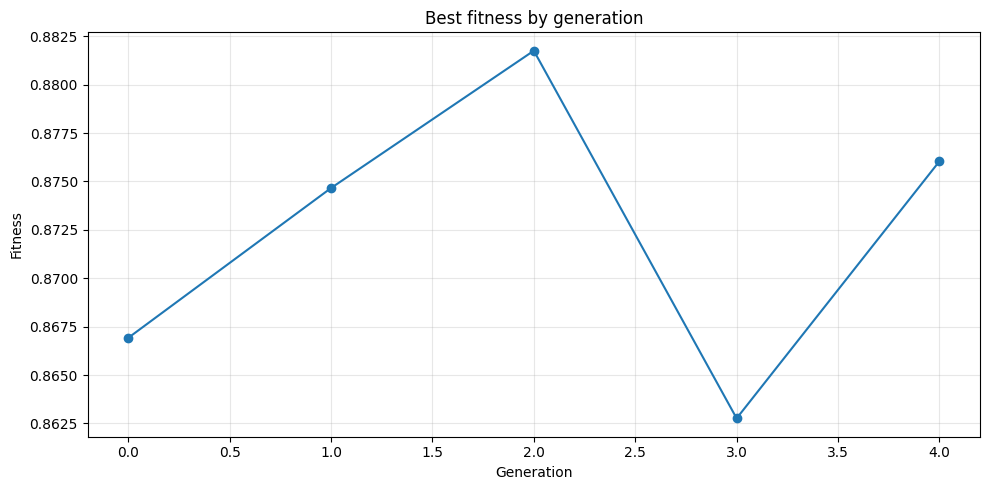

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
best_by_generation = evolution_df.groupby("generation")["fitness"].max()
best_by_generation.plot(marker="o", ax=ax)
ax.set_title("Best fitness by generation")
ax.set_xlabel("Generation")
ax.set_ylabel("Fitness")
ax.grid(True, alpha=0.3)
plt.tight_layout()

fig.savefig(FIGURES_DIR / "best_fitness_by_generation.png", dpi=200)
plt.show()

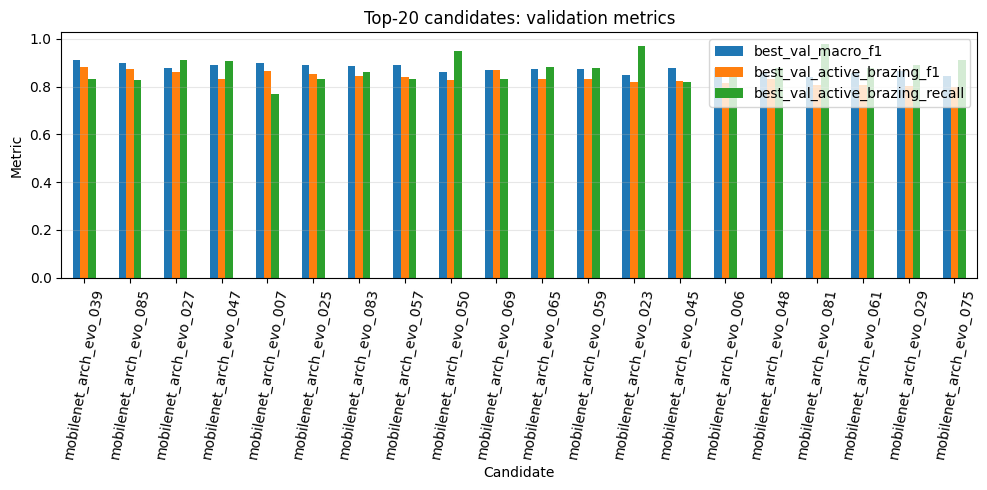

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
evolution_df.sort_values("fitness", ascending=False).head(20).plot(
    x="run_name",
    y=["best_val_macro_f1", "best_val_active_brazing_f1", "best_val_active_brazing_recall"],
    kind="bar",
    ax=ax,
)
ax.set_title("Top-20 candidates: validation metrics")
ax.set_xlabel("Candidate")
ax.set_ylabel("Metric")
ax.tick_params(axis="x", rotation=80)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

fig.savefig(FIGURES_DIR / "top20_validation_metrics.png", dpi=200)
plt.show()

### best evo

In [ ]:
best_final = evolution_df.iloc[0].to_dict()
best_final

{'run_name': 'mobilenet_arch_evo_039',
 'head_type': 'mlp_2',
 'head_hidden': 256,
 'head_bottleneck_ratio': 0.5,
 'dropout': 0.1,
 'activation': 'hardswish',
 'pooling': 'avg_max',
 'head_norm': 'none',
 'freeze_mode': 'full',
 'best_epoch': 10,
 'best_val_macro_f1': 0.909788075227306,
 'best_val_accuracy': 0.9514207149404216,
 'best_val_weighted_f1': 0.9529847129492932,
 'best_val_active_brazing_precision': 0.934959349593496,
 'best_val_active_brazing_recall': 0.8333333333333334,
 'best_val_active_brazing_f1': 0.8812260536398467,
 'num_params': 1255588,
 'num_trainable_params': 1255588,
 'num_classifier_params': 328580,
 'checkpoint': 'models/checkpoints/mobilenet_architecture_evolution/mobilenet_arch_evo_039_best.pt',
 'fitness': 0.8817515563875993,
 'generation': 2}

In [ ]:
def normalize_candidate_from_row(row: dict) -> dict:
    candidate = {
        "run_name": row["run_name"],
    }

    for key in ARCH_KEYS:
        candidate[key] = row[key]

    candidate["head_hidden"] = int(candidate["head_hidden"])
    candidate["head_bottleneck_ratio"] = float(candidate["head_bottleneck_ratio"])
    candidate["dropout"] = float(candidate["dropout"])

    return candidate

best_candidate = normalize_candidate_from_row(best_final)
best_candidate

{'run_name': 'mobilenet_arch_evo_039',
 'head_type': 'mlp_2',
 'head_hidden': 256,
 'head_bottleneck_ratio': 0.5,
 'dropout': 0.1,
 'activation': 'hardswish',
 'pooling': 'avg_max',
 'head_norm': 'none',
 'freeze_mode': 'full'}

In [ ]:
checkpoint_path = Path(best_final["checkpoint"])
checkpoint = torch.load(checkpoint_path, map_location=DEVICE)

best_model = create_mobilenet_v3_small_evo(
    best_candidate,
    num_classes=NUM_CLASSES,
    pretrained=True,
).to(DEVICE)

best_model.load_state_dict(checkpoint["model_state_dict"])
best_model.eval()

MobileNetV3SmallEvo(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=

### test

Best MobileNetV3 architecture evolution — test split
--------------------------------------------------------------------------------
accuracy:    0.9013
macro_f1:    0.7792
weighted_f1: 0.8942
active_brazing_f1:     0.5988
active_brazing_recall: 0.4949

                      precision    recall  f1-score   support

inactive_preparation     0.9762    0.9830    0.9796      1000
     flux_activation     0.6336    0.6014    0.6171       138
      active_brazing     0.7578    0.4949    0.5988       196
       stabilization     0.8541    1.0000    0.9213       398

            accuracy                         0.9013      1732
           macro avg     0.8054    0.7698    0.7792      1732
        weighted avg     0.8961    0.9013    0.8942      1732



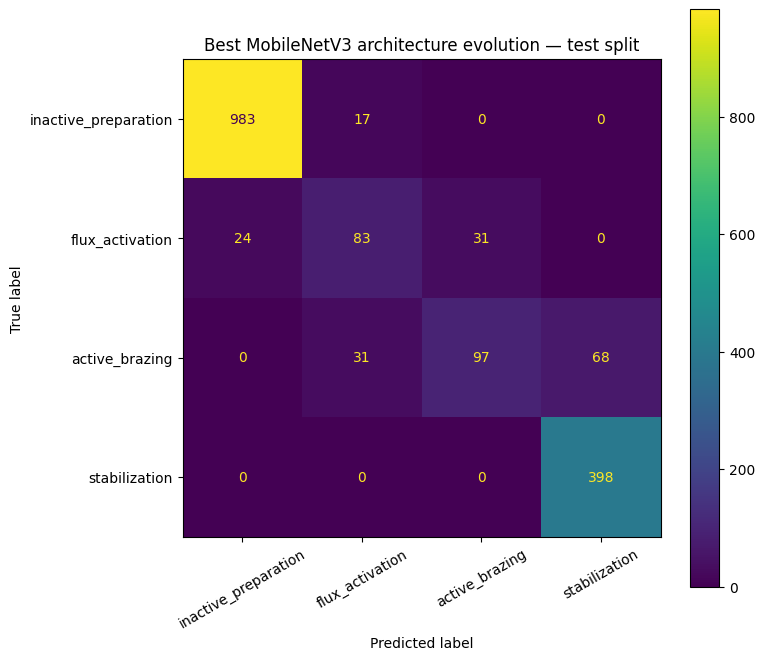

{'accuracy': 0.901270207852194,
 'macro_f1': 0.7791833999732863,
 'weighted_f1': 0.8942062942663228,
 'active_brazing_precision': 0.7578125,
 'active_brazing_recall': 0.49489795918367346,
 'active_brazing_f1': 0.5987654320987654,
 'confusion_matrix': [[983, 17, 0, 0],
  [24, 83, 31, 0],
  [0, 31, 97, 68],
  [0, 0, 0, 398]]}

In [ ]:
_, _, test_loader = make_dataloaders(
    image_size=FIXED_TRAINING_CONFIG["image_size"],
    augmentation=FIXED_TRAINING_CONFIG["augmentation"],
)

test_pred_df = predict_loader(best_model, test_loader)
test_pred_df.to_csv(REPORTS_DIR / "best_architecture_test_predictions.csv", index=False)

test_metrics = evaluate_predictions(
    test_pred_df,
    title="Best MobileNetV3 architecture evolution — test split",
)

test_summary = {
    "best_candidate": best_candidate,
    "checkpoint": str(checkpoint_path),
    "test_metrics": test_metrics,
    "fixed_training_config": FIXED_TRAINING_CONFIG,
}

with open(REPORTS_DIR / "best_architecture_test_summary.json", "w", encoding="utf-8") as f:
    json.dump(test_summary, f, ensure_ascii=False, indent=2)

test_metrics

### error pairs

In [ ]:
def get_error_pairs(pred_df: pd.DataFrame) -> pd.DataFrame:
    errors_df = pred_df[pred_df["stage_id"] != pred_df["pred_stage_id"]].copy()

    return (
        errors_df
        .groupby(["stage_name", "pred_stage_name"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .reset_index(drop=True)
    )


best_error_pairs_df = get_error_pairs(test_pred_df)

best_error_pairs_path = REPORTS_DIR / "best_architecture_test_error_pairs.csv"
best_error_pairs_df.to_csv(best_error_pairs_path, index=False)

print(f"Saved error pairs to: {best_error_pairs_path}")
best_error_pairs_df

Saved error pairs to: reports/mobilenet_architecture_evolution/best_architecture_test_error_pairs.csv


,stage_name,pred_stage_name,count
0,active_brazing,stabilization,68
1,active_brazing,flux_activation,31
2,flux_activation,active_brazing,31
3,flux_activation,inactive_preparation,24
4,inactive_preparation,flux_activation,17


### timeline

In [ ]:
def plot_predictions_for_video(pred_df: pd.DataFrame, video_id: str, run_name: str):
    video_df = pred_df[pred_df["video_id"] == video_id].sort_values("timestamp_s")

    if len(video_df) == 0:
        print(f"No rows for {video_id}")
        return

    plt.figure(figsize=(14, 4))

    plt.scatter(
        video_df["timestamp_s"],
        video_df["stage_id"],
        s=30,
        label="true",
        marker="o",
    )

    plt.scatter(
        video_df["timestamp_s"],
        video_df["pred_stage_id"],
        s=18,
        label="pred",
        marker="x",
    )

    plt.yticks([0, 1, 2, 3], STAGE_ORDER)
    plt.xlabel("Time, s")
    plt.ylabel("Stage")
    plt.title(f"True vs predicted stages — {video_id} — {run_name}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    safe_run_name = str(run_name).replace("/", "_")
    output_path = FIGURES_DIR / f"{video_id}_{safe_run_name}_timeline.png"
    plt.savefig(output_path, dpi=160)
    plt.show()

    return output_path

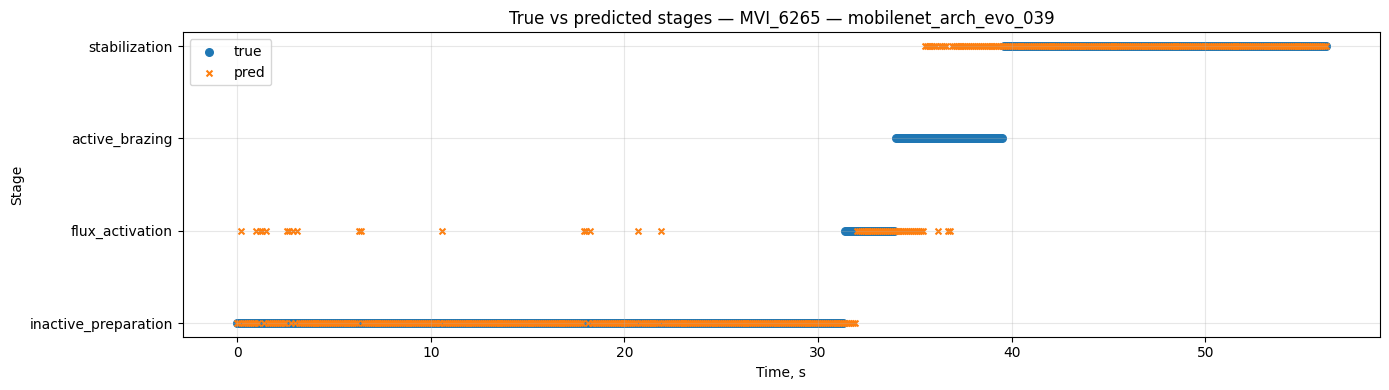

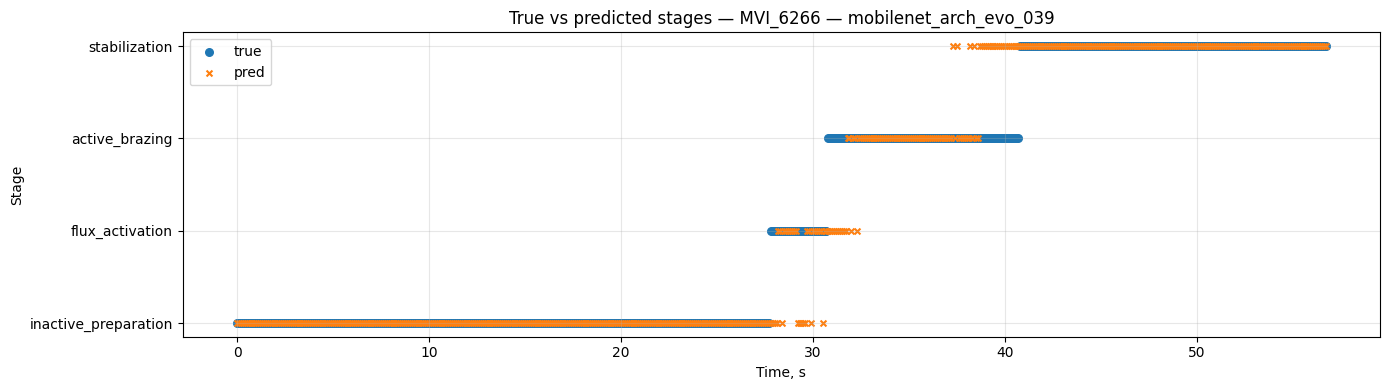

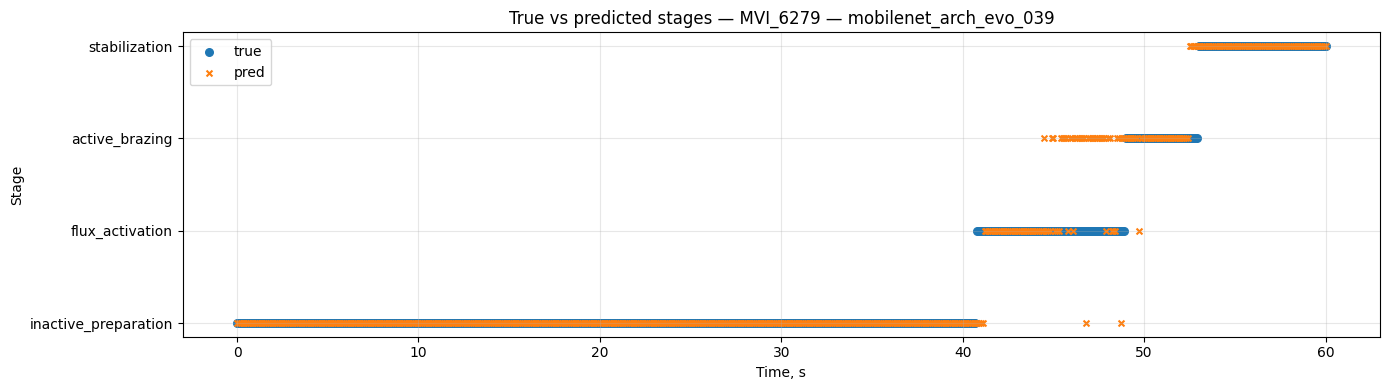

In [ ]:
run_name = best_candidate["run_name"]

for video_id in sorted(test_pred_df["video_id"].unique()):
    plot_predictions_for_video(
        pred_df=test_pred_df,
        video_id=video_id,
        run_name=run_name,
    )

## final retraining of top candidates

In [ ]:
FINAL_TOP_K = 5
FINAL_EPOCHS = 30

top_candidates = []

for i, row in evolution_df.head(FINAL_TOP_K).iterrows():
    candidate = {
        "run_name": f"mobilenet_arch_final_{i+1:02d}",
    }
    for key in ARCH_KEYS:
        candidate[key] = row[key]

    # csv может прочитать bool/числа как строки; нормализуем вручную
    candidate["head_hidden"] = int(candidate["head_hidden"])
    candidate["head_bottleneck_ratio"] = float(candidate["head_bottleneck_ratio"])
    candidate["dropout"] = float(candidate["dropout"])

    top_candidates.append(candidate)

pd.DataFrame(top_candidates)

,run_name,head_type,head_hidden,head_bottleneck_ratio,dropout,activation,pooling,head_norm,freeze_mode
0,mobilenet_arch_final_01,mlp_2,256,0.5,0.1,hardswish,avg_max,none,full
1,mobilenet_arch_final_02,mlp_1,256,1.0,0.1,hardswish,avg,batchnorm,full
2,mobilenet_arch_final_03,mlp_2,256,1.0,0.1,hardswish,avg,none,full
3,mobilenet_arch_final_04,mlp_1,256,1.0,0.1,hardswish,avg,none,full
4,mobilenet_arch_final_05,mlp_1,128,0.5,0.2,hardswish,avg,none,last_blocks


### retrainin

In [ ]:
FINAL_RESULTS = []

for candidate in top_candidates:
    result = train_candidate(
        candidate,
        epochs=FINAL_EPOCHS,
        save_checkpoint=True,
    )

    row = summarize_result(candidate, result)
    row["stage"] = "final_retrain"

    FINAL_RESULTS.append(row)

    del result
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

final_df = pd.DataFrame(FINAL_RESULTS)
final_df = final_df.sort_values("fitness", ascending=False).reset_index(drop=True)

final_df.to_csv(REPORTS_DIR / "mobilenet_architecture_final_retrain_results.csv", index=False)

# final_df[display_cols]

[mobilenet_arch_final_01] Epoch 01/30 | val_macro_f1=0.6910 val_active_f1=0.5312 val_active_recall=0.8333 | params=1,255,588 trainable=1,255,588 | 20.5s
[mobilenet_arch_final_01] Epoch 02/30 | val_macro_f1=0.7764 val_active_f1=0.6313 val_active_recall=0.8188 | params=1,255,588 trainable=1,255,588 | 21.1s
[mobilenet_arch_final_01] Epoch 03/30 | val_macro_f1=0.7933 val_active_f1=0.6721 val_active_recall=0.8986 | params=1,255,588 trainable=1,255,588 | 20.8s
[mobilenet_arch_final_01] Epoch 04/30 | val_macro_f1=0.8101 val_active_f1=0.7553 val_active_recall=0.9058 | params=1,255,588 trainable=1,255,588 | 21.0s
[mobilenet_arch_final_01] Epoch 05/30 | val_macro_f1=0.8101 val_active_f1=0.7762 val_active_recall=0.9928 | params=1,255,588 trainable=1,255,588 | 20.9s
[mobilenet_arch_final_01] Epoch 06/30 | val_macro_f1=0.7674 val_active_f1=0.6787 val_active_recall=0.9565 | params=1,255,588 trainable=1,255,588 | 21.1s
[mobilenet_arch_final_01] Epoch 07/30 | val_macro_f1=0.7874 val_active_f1=0.6684 v

KeyError: "['generation'] not in index"

In [ ]:
display_cols_2 = list(display_cols)
display_cols_2.remove('generation')
final_df[display_cols_2]

,run_name,fitness,best_val_macro_f1,best_val_active_brazing_f1,best_val_active_brazing_recall,num_params,num_trainable_params,num_classifier_params,head_type,head_hidden,head_bottleneck_ratio,dropout,activation,pooling,head_norm,freeze_mode
0,mobilenet_arch_final_03,0.917672,0.933501,0.912409,0.905797,1141540,1141540,214532,mlp_2,256,1.0,0.1,hardswish,avg,none,full
1,mobilenet_arch_final_05,0.887105,0.905564,0.888031,0.833333,1001380,719012,74372,mlp_1,128,0.5,0.2,hardswish,avg,none,last_blocks
2,mobilenet_arch_final_04,0.869788,0.896293,0.852941,0.840580,1075748,1075748,148740,mlp_1,256,1.0,0.1,hardswish,avg,none,full
3,mobilenet_arch_final_02,0.834112,0.872003,0.813688,0.775362,1076260,1076260,149252,mlp_1,256,1.0,0.1,hardswish,avg,batchnorm,full
4,mobilenet_arch_final_01,0.826788,0.838955,0.797428,0.898551,1255588,1255588,328580,mlp_2,256,0.5,0.1,hardswish,avg_max,none,full


### test candidates

In [ ]:
def evaluate_final_df_compact(final_df: pd.DataFrame) -> pd.DataFrame:
    rows = []

    _, _, test_loader = make_dataloaders(
        image_size=FIXED_TRAINING_CONFIG["image_size"],
        augmentation=FIXED_TRAINING_CONFIG["augmentation"],
    )

    for _, row in final_df.iterrows():
        row_dict = row.to_dict()
        candidate = normalize_candidate_from_row(row_dict)

        run_name = candidate["run_name"]
        checkpoint_path = Path(row_dict["checkpoint"])

        checkpoint = torch.load(checkpoint_path, map_location=DEVICE)

        model = create_mobilenet_v3_small_evo(
            candidate,
            num_classes=NUM_CLASSES,
            pretrained=True,
        ).to(DEVICE)

        model.load_state_dict(checkpoint["model_state_dict"])
        model.eval()

        pred_df = predict_loader(model, test_loader)
        metrics = classification_metrics_from_pred_df(pred_df)

        rows.append({
            "run_name": run_name,

            "test_accuracy": metrics["accuracy"],
            "test_macro_f1": metrics["macro_f1"],
            "test_weighted_f1": metrics["weighted_f1"],
            "test_active_brazing_f1": metrics["active_brazing_f1"],
            "test_active_brazing_recall": metrics["active_brazing_recall"],

            "best_val_macro_f1": row_dict.get("best_val_macro_f1"),
            "best_val_active_brazing_f1": row_dict.get("best_val_active_brazing_f1"),
            "best_val_active_brazing_recall": row_dict.get("best_val_active_brazing_recall"),
            "fitness": row_dict.get("fitness"),

            "head_type": candidate["head_type"],
            "head_hidden": candidate["head_hidden"],
            "head_bottleneck_ratio": candidate["head_bottleneck_ratio"],
            "dropout": candidate["dropout"],
            "activation": candidate["activation"],
            "pooling": candidate["pooling"],
            "head_norm": candidate["head_norm"],
            "freeze_mode": candidate["freeze_mode"],

            "checkpoint": str(checkpoint_path),
        })

        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return (
        pd.DataFrame(rows)
        .sort_values("test_macro_f1", ascending=False)
        .reset_index(drop=True)
    )


final_test_compact_df = evaluate_final_df_compact(final_df)
final_test_compact_df

,run_name,test_accuracy,test_macro_f1,test_weighted_f1,test_active_brazing_f1,test_active_brazing_recall,best_val_macro_f1,best_val_active_brazing_f1,best_val_active_brazing_recall,fitness,head_type,head_hidden,head_bottleneck_ratio,dropout,activation,pooling,head_norm,freeze_mode,checkpoint
0,mobilenet_arch_final_05,0.898961,0.786518,0.893947,0.560811,0.423469,0.905564,0.888031,0.833333,0.887105,mlp_1,128,0.5,0.2,hardswish,avg,none,last_blocks,models/checkpoints/mobilenet_architecture_evol...
1,mobilenet_arch_final_04,0.901270,0.757455,0.883850,0.425703,0.270408,0.896293,0.852941,0.840580,0.869788,mlp_1,256,1.0,0.1,hardswish,avg,none,full,models/checkpoints/mobilenet_architecture_evol...
2,mobilenet_arch_final_01,0.842379,0.709476,0.847611,0.555270,0.551020,0.838955,0.797428,0.898551,0.826788,mlp_2,256,0.5,0.1,hardswish,avg_max,none,full,models/checkpoints/mobilenet_architecture_evol...
3,mobilenet_arch_final_03,0.733256,0.656709,0.769559,0.536817,0.576531,0.933501,0.912409,0.905797,0.917672,mlp_2,256,1.0,0.1,hardswish,avg,none,full,models/checkpoints/mobilenet_architecture_evol...
4,mobilenet_arch_final_02,0.732679,0.613297,0.756427,0.343096,0.209184,0.872003,0.813688,0.775362,0.834112,mlp_1,256,1.0,0.1,hardswish,avg,batchnorm,full,models/checkpoints/mobilenet_architecture_evol...


## test evaluation of best final candidate

In [ ]:
best_final = final_df.iloc[1].to_dict()
best_final

{'run_name': 'mobilenet_arch_final_05',
 'head_type': 'mlp_1',
 'head_hidden': 128,
 'head_bottleneck_ratio': 0.5,
 'dropout': 0.2,
 'activation': 'hardswish',
 'pooling': 'avg',
 'head_norm': 'none',
 'freeze_mode': 'last_blocks',
 'best_epoch': 22,
 'best_val_macro_f1': 0.9055640593898364,
 'best_val_accuracy': 0.9486709440879927,
 'best_val_weighted_f1': 0.9502982425792362,
 'best_val_active_brazing_precision': 0.9504132231404959,
 'best_val_active_brazing_recall': 0.8333333333333334,
 'best_val_active_brazing_f1': 0.888030888030888,
 'num_params': 1001380,
 'num_trainable_params': 719012,
 'num_classifier_params': 74372,
 'checkpoint': 'models/checkpoints/mobilenet_architecture_evolution/mobilenet_arch_final_05_best.pt',
 'fitness': 0.8871054005057291,
 'stage': 'final_retrain'}

In [ ]:
def normalize_candidate_from_row(row: dict) -> dict:
    candidate = {
        "run_name": row["run_name"],
    }

    for key in ARCH_KEYS:
        candidate[key] = row[key]

    candidate["head_hidden"] = int(candidate["head_hidden"])
    candidate["head_bottleneck_ratio"] = float(candidate["head_bottleneck_ratio"])
    candidate["dropout"] = float(candidate["dropout"])

    return candidate

best_candidate = normalize_candidate_from_row(best_final)
best_candidate

{'run_name': 'mobilenet_arch_final_05',
 'head_type': 'mlp_1',
 'head_hidden': 128,
 'head_bottleneck_ratio': 0.5,
 'dropout': 0.2,
 'activation': 'hardswish',
 'pooling': 'avg',
 'head_norm': 'none',
 'freeze_mode': 'last_blocks'}

In [ ]:
checkpoint_path = Path(best_final["checkpoint"])
checkpoint = torch.load(checkpoint_path, map_location=DEVICE)

best_model = create_mobilenet_v3_small_evo(
    best_candidate,
    num_classes=NUM_CLASSES,
    pretrained=True,
).to(DEVICE)

best_model.load_state_dict(checkpoint["model_state_dict"])
best_model.eval()

MobileNetV3SmallEvo(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=

### test

Best MobileNetV3 architecture evolution [retraining] — test split
--------------------------------------------------------------------------------
accuracy:    0.8990
macro_f1:    0.7865
weighted_f1: 0.8939
active_brazing_f1:     0.5608
active_brazing_recall: 0.4235

                      precision    recall  f1-score   support

inactive_preparation     0.9878    0.9750    0.9814      1000
     flux_activation     0.5789    0.8768    0.6974       138
      active_brazing     0.8300    0.4235    0.5608       196
       stabilization     0.8670    0.9497    0.9065       398

            accuracy                         0.8990      1732
           macro avg     0.8159    0.8063    0.7865      1732
        weighted avg     0.9096    0.8990    0.8939      1732



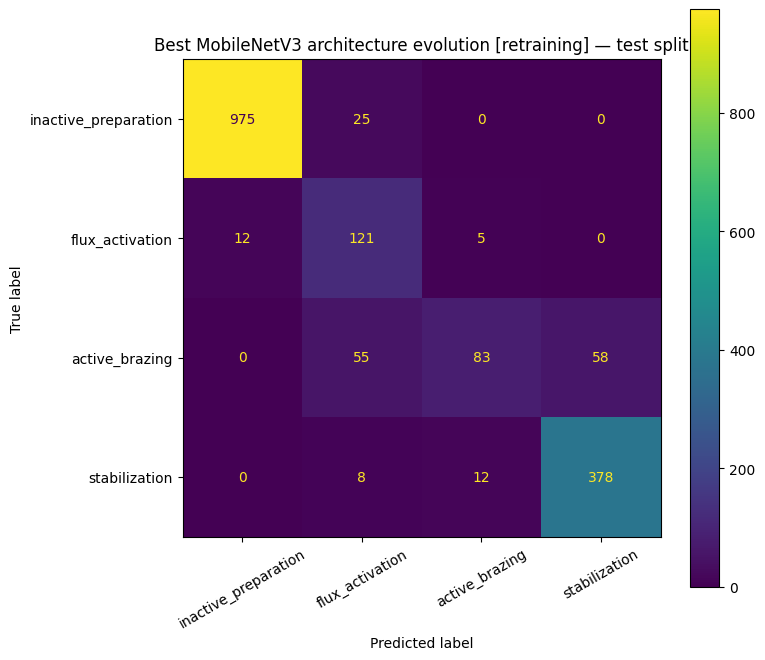

{'accuracy': 0.898960739030023,
 'macro_f1': 0.7865177335683826,
 'weighted_f1': 0.8939474223587396,
 'active_brazing_precision': 0.83,
 'active_brazing_recall': 0.42346938775510207,
 'active_brazing_f1': 0.5608108108108109,
 'confusion_matrix': [[975, 25, 0, 0],
  [12, 121, 5, 0],
  [0, 55, 83, 58],
  [0, 8, 12, 378]]}

In [ ]:
_, _, test_loader = make_dataloaders(
    image_size=FIXED_TRAINING_CONFIG["image_size"],
    augmentation=FIXED_TRAINING_CONFIG["augmentation"],
)

test_pred_df = predict_loader(best_model, test_loader)
test_pred_df.to_csv(REPORTS_DIR / "best_architecture_retraining_test_predictions.csv", index=False)

test_metrics = evaluate_predictions(
    test_pred_df,
    title="Best MobileNetV3 architecture evolution [retraining] — test split",
)

test_summary = {
    "best_candidate": best_candidate,
    "checkpoint": str(checkpoint_path),
    "test_metrics": test_metrics,
    "fixed_training_config": FIXED_TRAINING_CONFIG,
}

with open(REPORTS_DIR / "best_architecture_retraining_test_summary.json", "w", encoding="utf-8") as f:
    json.dump(test_summary, f, ensure_ascii=False, indent=2)

test_metrics

### error pairs

In [ ]:
def get_error_pairs(pred_df: pd.DataFrame) -> pd.DataFrame:
    errors_df = pred_df[pred_df["stage_id"] != pred_df["pred_stage_id"]].copy()

    return (
        errors_df
        .groupby(["stage_name", "pred_stage_name"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .reset_index(drop=True)
    )


best_error_pairs_df = get_error_pairs(test_pred_df)

best_error_pairs_path = REPORTS_DIR / "best_architecture_retraining_test_error_pairs.csv"
best_error_pairs_df.to_csv(best_error_pairs_path, index=False)

print(f"Saved error pairs to: {best_error_pairs_path}")
best_error_pairs_df

Saved error pairs to: reports/mobilenet_architecture_evolution/best_architecture_retraining_test_error_pairs.csv


,stage_name,pred_stage_name,count
0,active_brazing,stabilization,58
1,active_brazing,flux_activation,55
2,inactive_preparation,flux_activation,25
3,stabilization,active_brazing,12
4,flux_activation,inactive_preparation,12
5,stabilization,flux_activation,8
6,flux_activation,active_brazing,5


### timeline

In [ ]:
def plot_predictions_for_video(pred_df: pd.DataFrame, video_id: str, run_name: str):
    video_df = pred_df[pred_df["video_id"] == video_id].sort_values("timestamp_s")

    if len(video_df) == 0:
        print(f"No rows for {video_id}")
        return

    plt.figure(figsize=(14, 4))

    plt.scatter(
        video_df["timestamp_s"],
        video_df["stage_id"],
        s=30,
        label="true",
        marker="o",
    )

    plt.scatter(
        video_df["timestamp_s"],
        video_df["pred_stage_id"],
        s=18,
        label="pred",
        marker="x",
    )

    plt.yticks([0, 1, 2, 3], STAGE_ORDER)
    plt.xlabel("Time, s")
    plt.ylabel("Stage")
    plt.title(f"True vs predicted stages — {video_id} — {run_name}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    safe_run_name = str(run_name).replace("/", "_")
    output_path = FIGURES_DIR / f"{video_id}_{safe_run_name}_timeline.png"
    plt.savefig(output_path, dpi=160)
    plt.show()

    return output_path

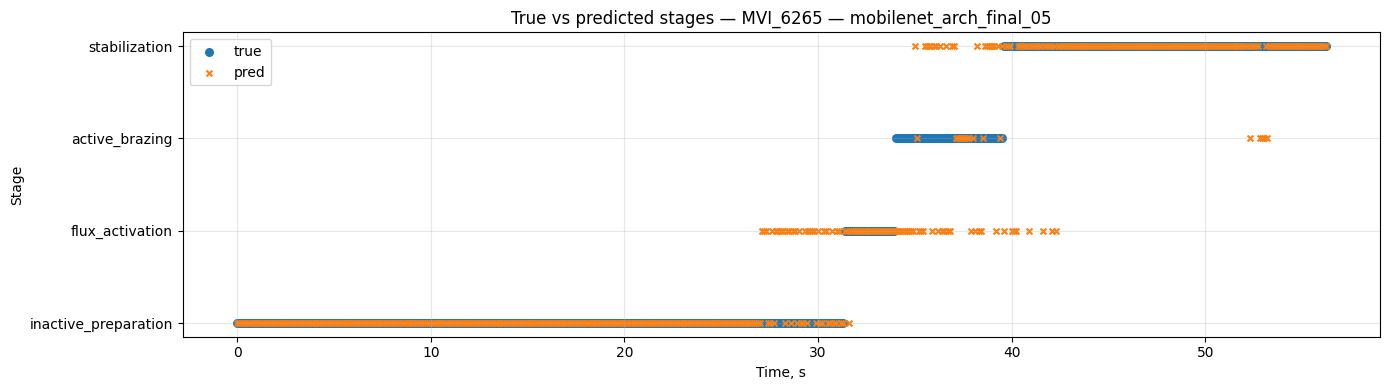

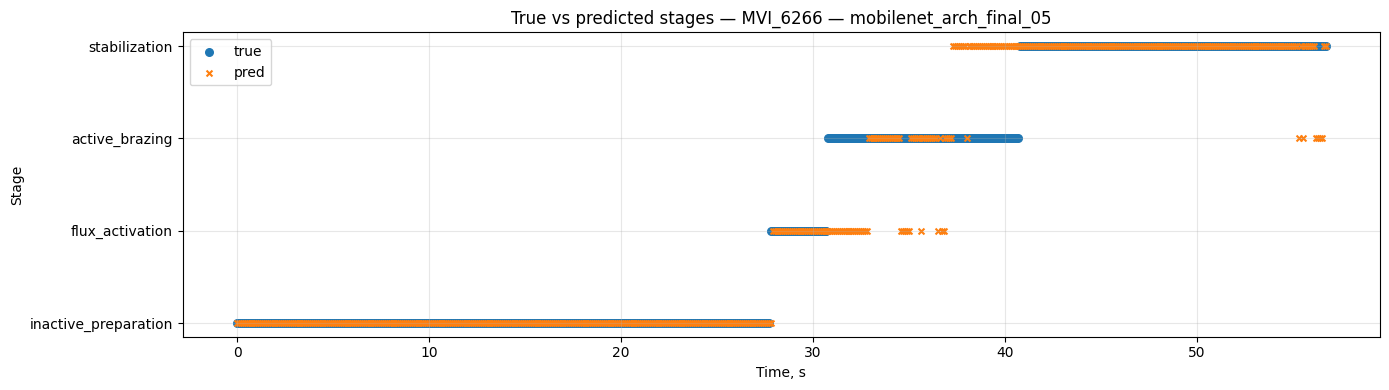

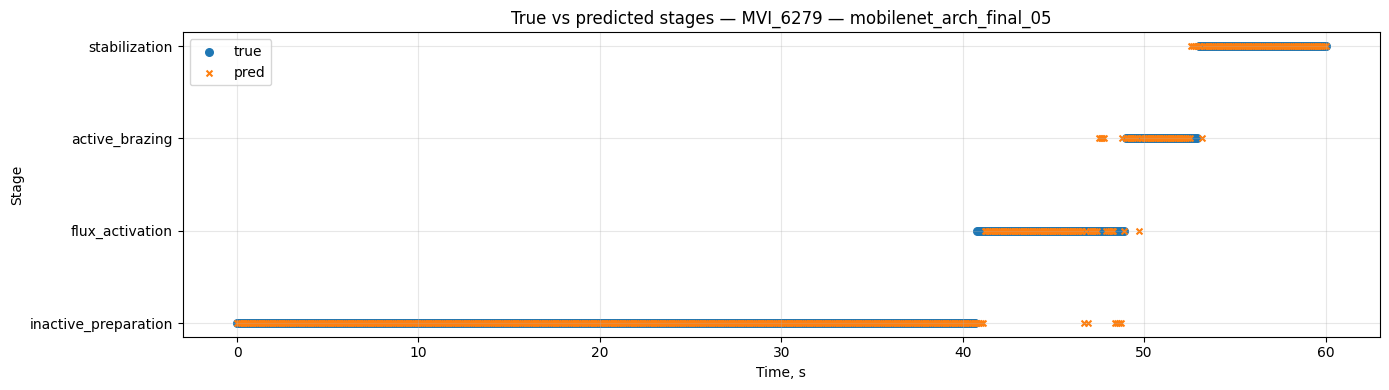

In [ ]:
run_name = best_candidate["run_name"]

for video_id in sorted(test_pred_df["video_id"].unique()):
    plot_predictions_for_video(
        pred_df=test_pred_df,
        video_id=video_id,
        run_name=run_name,
    )

# results

In [ ]:
!cp -r "$CHECKPOINTS_DIR"/. "$DRIVE_CHECKPOINTS_DIR"/

В ноутбуке был проведён эволюционный поиск конфигурации классификационной головы и режима дообучения для `MobileNetV3 Small` при фиксированном pretrained backbone. Поиск изменял тип classifier head, размер скрытого представления, bottleneck ratio, dropout, функцию активации, pooling, нормализацию в голове и режим fine-tuning backbone. Поэтому данный эксперимент следует интерпретировать как lightweight NAS-like search по classifier head и fine-tuning strategy, а не как полноценный поиск всей архитектуры MobileNetV3.

Лучшей конфигурацией по итогам эволюционного поиска стала `mobilenet_arch_evo_039`: `mlp_2`, `hidden=256`, `bottleneck=0.5`, `dropout=0.1`, `hardswish`, `avg_max pooling`, без нормализации головы, `full fine-tune`. На validation она достигла `macro-F1 = 0.9098`, `active_brazing F1 = 0.8812`, `active_brazing recall = 0.8333`.

На test split модель `mobilenet_arch_evo_039` показала `accuracy = 0.9013`, `macro-F1 = 0.7792`, `weighted-F1 = 0.8942`, `active_brazing F1 = 0.5988`, `active_brazing recall = 0.4949`. Основные ошибки связаны с недораспознаванием `active_brazing`: часть кадров этой стадии относится к `stabilization` и `flux_activation`.

Дополнительный retraining top-5 архитектур на 30 эпох не привёл к устойчивому улучшению. Лучший retrained-кандидат по test macro-F1 (`mobilenet_arch_final_05`) достиг `macro-F1 = 0.7865`, но уступил `mobilenet_arch_evo_039` по `active_brazing F1` и `active_brazing recall`, а также показал нежелательные поздние выбросы `active_brazing` в зоне `stabilization` на timeline. Validation-лидер retraining (`mobilenet_arch_final_03`) заметно просел на test, что указывает на нестабильность длинного дообучения на малом наборе данных.

Итоговый вывод: эволюционный поиск classifier head оказался полезным и выявил устойчивые архитектурные предпочтения для задачи: небольшие MLP-головы, `hardswish`, небольшой dropout, `avg`/`avg_max pooling` и полный fine-tune backbone. При этом дополнительное 30-epoch retraining не следует считать обязательным улучшением. В качестве основного результата ноутбука целесообразно использовать `mobilenet_arch_evo_039`, а retrained-модели рассматривать как дополнительные проверочные варианты.